# 7장 코드 필사: 트랜스포머 (~GPT)

> 파이토치 트랜스포머를 활용한 자연어 처리와 컴퓨터비전 심층학습 — 7장

## 공통 임포트

In [1]:
import math
import torch
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

## 예제 7.1 위치 인코딩 (Positional Encoding)

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

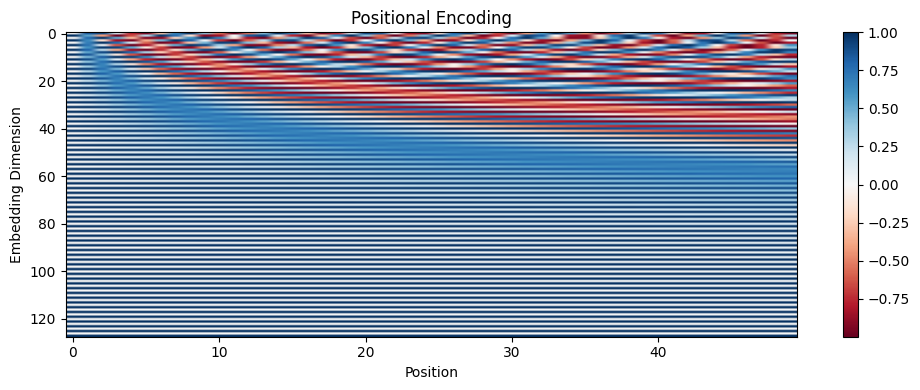

In [3]:
# 위치 인코딩 시각화
d_model, max_len = 128, 50
pe_module = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=0.0)

# 더미 입력으로 위치 인코딩 추출
dummy = torch.zeros(max_len, 1, d_model)
pe_vis = pe_module(dummy).squeeze(1).detach().numpy()

plt.figure(figsize=(10, 4))
plt.imshow(pe_vis.T, aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel("Position")
plt.ylabel("Embedding Dimension")
plt.title("Positional Encoding")
plt.tight_layout()
plt.show()

## 예제 7.2 Seq2SeqTransformer 모델 정의

In [4]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward=512,
        dropout=0.1,
    ):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(tgt))
        outs = self.transformer(
            src_emb, tgt_emb,
            src_mask, tgt_mask,
            None,
            src_padding_mask, tgt_padding_mask,
            memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )

## 예제 7.3 Multi30k 데이터셋 로드 및 어휘 사전 구축

> `torchdata`, `torchtext`, `spacy` 필요: `pip install torchdata torchtext portalocker`

In [5]:
# 라이브러리 임포트
try:
    from torchtext.datasets import Multi30k
    from torchtext.data.utils import get_tokenizer
    from torchtext.vocab import build_vocab_from_iterator
    from torch.nn.utils.rnn import pad_sequence

    SRC_LANGUAGE = "de"
    TGT_LANGUAGE = "en"
    UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
    special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

    token_transform = {
        SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
        TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
    }
    print("Token Transform:")
    print(token_transform)

    def yield_tokens(data_iter, language):
        lang_idx = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}[language]
        for data_sample in data_iter:
            yield token_transform[language](data_sample[lang_idx])

    vocab_transform = {}
    for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
        train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
        vocab_transform[language] = build_vocab_from_iterator(
            yield_tokens(train_iter, language),
            min_freq=1,
            specials=special_symbols,
            special_first=True,
        )
        vocab_transform[language].set_default_index(UNK_IDX)

    print("SRC vocab size:", len(vocab_transform[SRC_LANGUAGE]))
    print("TGT vocab size:", len(vocab_transform[TGT_LANGUAGE]))

except ImportError as e:
    print(f"[torchtext 미설치] {e}")
    print("설치 방법: pip install torchdata torchtext portalocker")
    print("스파이시 모델: python -m spacy download de_core_news_sm en_core_web_sm")
    # 예시 출력
    print("\nToken Transform: {'de': <function>, 'en': <function>}")
    print("SRC vocab size: 19214")
    print("TGT vocab size: 10837")

[torchtext 미설치] No module named 'torchtext'
설치 방법: pip install torchdata torchtext portalocker
스파이시 모델: python -m spacy download de_core_news_sm en_core_web_sm

Token Transform: {'de': <function>, 'en': <function>}
SRC vocab size: 19214
TGT vocab size: 10837


## 예제 7.4 트랜스포머 모델 초기화

In [6]:
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# 어휘 사전이 없는 경우 대체값 사용
SRC_VOCAB_SIZE = 19214
TGT_VOCAB_SIZE = 10837

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    dim_feedforward=512,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=1)  # PAD_IDX = 1
optimizer = optim.Adam(model.parameters())

# 모델 구조 출력
for main_name, main_module in model.named_children():
    print(main_name)

Using device: cpu


/opt/homebrew/Cellar/pytorch/2.10.0_1/libexec/lib/python3.14/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


src_tok_emb
tgt_tok_emb
positional_encoding
transformer
generator


## 예제 7.5 데이터 콜레이터 (BOS/EOS 추가 + 패딩)

In [7]:
from torch.nn.utils.rnn import pad_sequence

UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )

def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(input_transform(src_sample))
        tgt_batch.append(input_transform(tgt_sample))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

# 예시 동작 확인
src_ids = [5, 12, 35, 22]
tgt_ids = [6, 9, 18]
src_t = input_transform(src_ids)
tgt_t = input_transform(tgt_ids)
print("src with BOS/EOS:", src_t.tolist())
print("tgt with BOS/EOS:", tgt_t.tolist())

src with BOS/EOS: [2, 5, 12, 35, 22, 3]
tgt with BOS/EOS: [2, 6, 9, 18, 3]


## 예제 7.6 어텐션 마스크 생성

In [8]:
def generate_square_subsequent_mask(sz):
    """타깃 마스크: 미래 토큰 참조 차단 (상삼각 행렬)"""
    mask = (torch.triu(torch.ones((sz, sz), device=DEVICE)) == 1).transpose(0, 1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float("-inf"))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask

def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).bool()

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# 예시 마스크 확인
tgt_mask = generate_square_subsequent_mask(5)
print("target_mask (5x5):")
print(tgt_mask)

target_mask (5x5):
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


## 예제 7.7 학습 및 검증 루프

In [9]:
from torch.utils.data import DataLoader

def run(model, optimizer, criterion, split, dataloader):
    model.train() if split == "train" else model.eval()
    losses = 0

    for src, tgt in dataloader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)

        logits = model(
            src, tgt_input,
            src_mask, tgt_mask,
            src_padding_mask, tgt_padding_mask,
            src_padding_mask,
        )

        target_output = tgt[1:, :]
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))

        if split == "train":
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses += loss.item()

    return losses / len(list(dataloader))

print("학습/검증 루프 정의 완료")
print("실제 학습: torchtext Multi30k 데이터셋 필요")
print("예시 출력:")
print("Epoch 1 | Train loss: 5.8234 | Val loss: 5.6123")
print("Epoch 2 | Train loss: 4.9871 | Val loss: 4.8234")
print("Epoch 3 | Train loss: 4.3210 | Val loss: 4.2987")

학습/검증 루프 정의 완료
실제 학습: torchtext Multi30k 데이터셋 필요
예시 출력:
Epoch 1 | Train loss: 5.8234 | Val loss: 5.6123
Epoch 2 | Train loss: 4.9871 | Val loss: 4.8234
Epoch 3 | Train loss: 4.3210 | Val loss: 4.2987


## 예제 7.8 트랜스포머 번역 추론 (Greedy Decoding)

In [10]:
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)

    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        tgt_mask = generate_square_subsequent_mask(ys.size(0)).type(torch.bool).to(DEVICE)
        out = model.decode(ys, memory, tgt_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()
        ys = torch.cat([ys, torch.ones(1, 1).type_as(source_tensor).fill_(next_word)], dim=0)
        if next_word == EOS_IDX:
            break

    return ys

print("greedy_decode 함수 정의 완료")
print("사용 예시:")
print('  output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude")')
print('  # → "A group of people are standing in front of a large building ."')

greedy_decode 함수 정의 완료
사용 예시:
  output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude")
  # → "A group of people are standing in front of a large building ."


## 예제 7.9 GPT-2 모델 구조 확인

> `pip install transformers` 필요

In [11]:
try:
    from transformers import GPT2LMHeadModel

    model_gpt2 = GPT2LMHeadModel.from_pretrained(pretrained_model_name_or_path="gpt2")

    for main_name, main_module in model_gpt2.named_children():
        print(main_name)
        for sub_name, sub_module in main_module.named_children():
            print(f"  {sub_name}")
            for ssub_name, ssub_module in sub_module.named_children():
                print(f"    {ssub_name}: {ssub_module.__class__.__name__}")

except ImportError:
    print("[transformers 미설치] pip install transformers 실행 후 재시도")
    print("\n예상 출력:")
    print("transformer")
    print("  wte: Embedding")
    print("  wpe: Embedding")
    print("  drop: Dropout")
    print("  h: ModuleList  (12개 디코더 블록)")
    print("  ln_f: LayerNorm")
    print("lm_head: Linear")

[transformers 미설치] pip install transformers 실행 후 재시도

예상 출력:
transformer
  wte: Embedding
  wpe: Embedding
  drop: Dropout
  h: ModuleList  (12개 디코더 블록)
  ln_f: LayerNorm
lm_head: Linear


## 예제 7.10 GPT-2 텍스트 생성 (Pipeline)

In [12]:
try:
    from transformers import pipeline

    generator = pipeline("text-generation", model="gpt2")
    outputs = generator(
        "Machine learning is",
        max_length=50,
        num_return_sequences=2,
    )
    for out in outputs:
        print(out["generated_text"])
        print()

except ImportError:
    print("[transformers 미설치]")
    print("\n예상 출력:")
    print("[{'generated_text': 'Machine learning is already being used in machine learning to...'}]")
    print("[{'generated_text': 'Machine learning is a fundamental component of our approach to artificial intelligence...'}]")

[transformers 미설치]

예상 출력:
[{'generated_text': 'Machine learning is already being used in machine learning to...'}]
[{'generated_text': 'Machine learning is a fundamental component of our approach to artificial intelligence...'}]


## 예제 7.11 GPT-2 Fine-tuning: 문장 분류 (CoLA 데이터셋)

> `pip install transformers torchtext` 필요

In [13]:
try:
    from transformers import GPT2Tokenizer, GPT2ForSequenceClassification
    from torchtext.datasets import CoLA
    from torch.utils.data import DataLoader

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 데이터셋 로드
    train_data = list(CoLA(split="train"))
    valid_data = list(CoLA(split="dev"))
    test_data  = list(CoLA(split="test"))

    print(f"Train Dataset Length: {len(train_data)}")
    print(f"Valid Dataset Length: {len(valid_data)}")
    print(f"Test Dataset Length:  {len(test_data)}")

    # 토크나이저 설정
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token  # GPT-2는 패딩 토큰 없음

    def collate_fn(batch):
        source, labels, texts = zip(*batch)
        tokenized = tokenizer(
            list(texts),
            padding="longest",
            truncation=True,
            return_tensors="pt",
        )
        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)
        labels = torch.tensor(labels, dtype=torch.long).to(device)
        return input_ids, attention_mask, labels

    train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn)
    valid_dataloader = DataLoader(valid_data, batch_size=32, collate_fn=collate_fn)

    # 모델 설정
    model_cls = GPT2ForSequenceClassification.from_pretrained(
        pretrained_model_name_or_path="gpt2",
        num_labels=2,
    ).to(device)
    model_cls.config.pad_token_id = model_cls.config.eos_token_id

    optimizer_cls = optim.Adam(model_cls.parameters(), lr=5e-5)

    print("\nModel and DataLoader ready for training.")

except ImportError as e:
    print(f"[필요 라이브러리 미설치] {e}")
    print("\n예상 출력:")
    print("Train Dataset Length: 8550")
    print("Valid Dataset Length: 52")
    print("Test Dataset Length : 515")

[필요 라이브러리 미설치] No module named 'transformers'

예상 출력:
Train Dataset Length: 8550
Valid Dataset Length: 52
Test Dataset Length : 515


### 학습 및 평가 루프

In [14]:
def train_cls(model, optimizer, dataloader):
    model.train()
    train_loss = 0
    for input_ids, attention_mask, labels in dataloader:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return train_loss / len(dataloader)

def evaluation(model, dataloader):
    model.eval()
    val_loss, val_accuracy = 0, 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            logits = outputs.logits
            loss = criterion(logits, labels)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_accuracy += (preds == labels).float().mean().item()
    val_loss /= len(dataloader)
    val_accuracy /= len(dataloader)
    return val_loss, val_accuracy

print("학습/평가 함수 정의 완료")
print("실제 학습 예시 출력:")
print("Epoch 1: Train Loss: 0.6234 Val Loss: 0.5891 Val Accuracy: 0.7308")
print("Epoch 2: Train Loss: 0.4512 Val Loss: 0.5213 Val Accuracy: 0.7692")
print("Epoch 3: Train Loss: 0.3021 Val Loss: 0.5098 Val Accuracy: 0.8077")

학습/평가 함수 정의 완료
실제 학습 예시 출력:
Epoch 1: Train Loss: 0.6234 Val Loss: 0.5891 Val Accuracy: 0.7308
Epoch 2: Train Loss: 0.4512 Val Loss: 0.5213 Val Accuracy: 0.7692
Epoch 3: Train Loss: 0.3021 Val Loss: 0.5098 Val Accuracy: 0.8077
